In [1]:
from google.colab import files
import zipfile
import os
import glob

uploaded = files.upload()

# Check uploaded files
print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

# Extract ZIP if a zip file was uploaded
for filename in uploaded.keys():
    if filename.endswith(".zip"):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall("/content/heart_failure_data")

print("\nExtracted files:")
for file in glob.glob("/content/heart_failure_data/**/*", recursive=True):
    print(file)

Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset (1).csv
Uploaded files:
heart_failure_clinical_records_dataset (1).csv

Extracted files:


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [6]:
from google.colab import files

uploaded = files.upload()

print("Uploaded file:")
for filename in uploaded.keys():
    print(filename)

Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset (2).csv
Uploaded file:
heart_failure_clinical_records_dataset (2).csv


In [7]:
import os
import pandas as pd

filename = list(uploaded.keys())[0]

print("File:", filename)
print("Size:", os.path.getsize(filename), "bytes")
print("Extension:", os.path.splitext(filename)[1])

File: heart_failure_clinical_records_dataset (2).csv
Size: 12239 bytes
Extension: .csv


In [8]:
df = pd.read_csv(filename)

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

✅ Dataset loaded successfully!
Shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [9]:
# Task 3: Summarize Dataset

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()

Number of Rows: 299
Number of Columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Dataset Information:
<class 'pandas.core.f

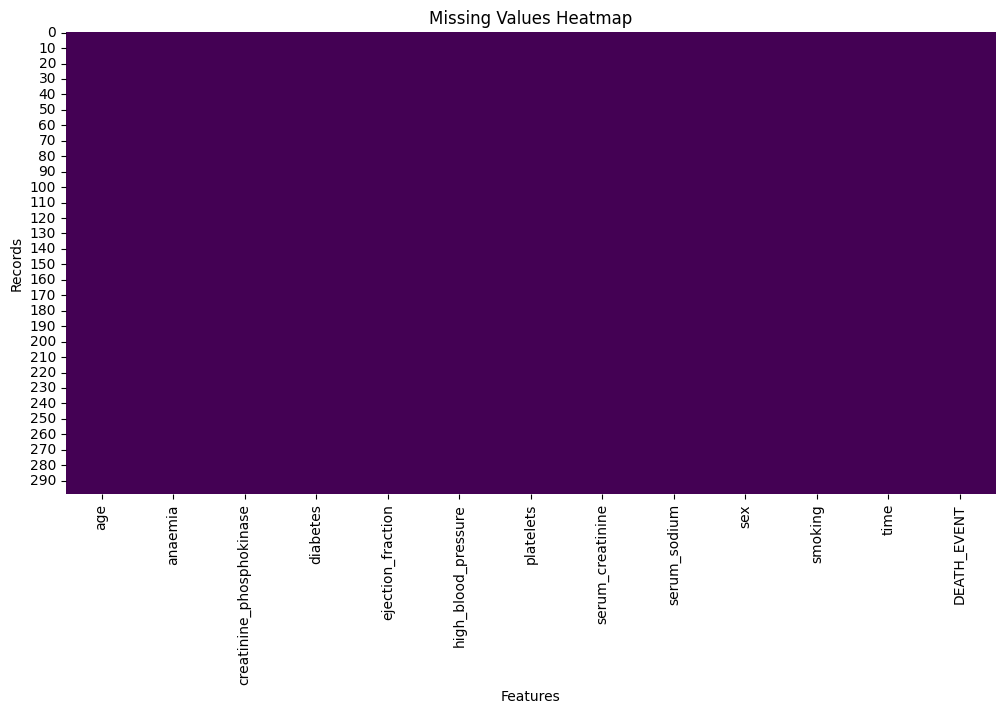

In [10]:
# Task 4: Visualize Missing Values

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Records")

plt.show()

Numerical Features:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']


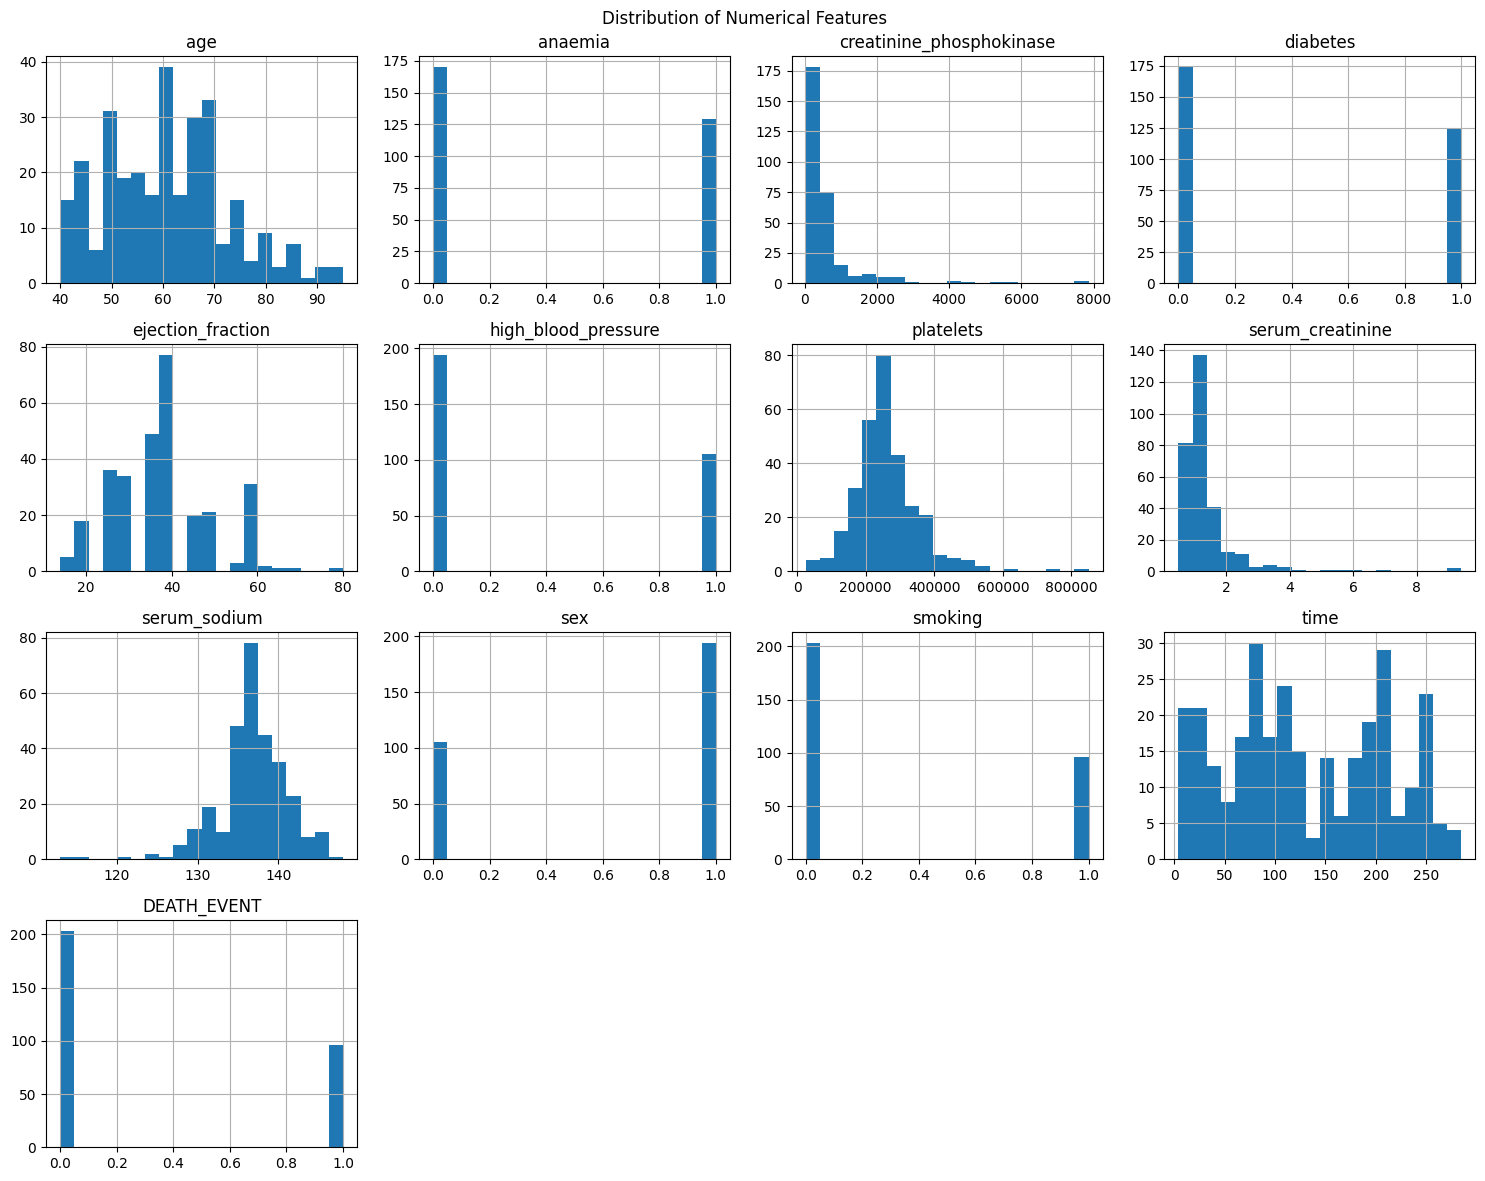

In [11]:
# Task 5: Plot Distributions

numerical_columns = df.select_dtypes(include='number').columns

print("Numerical Features:")
print(list(numerical_columns))

df[numerical_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

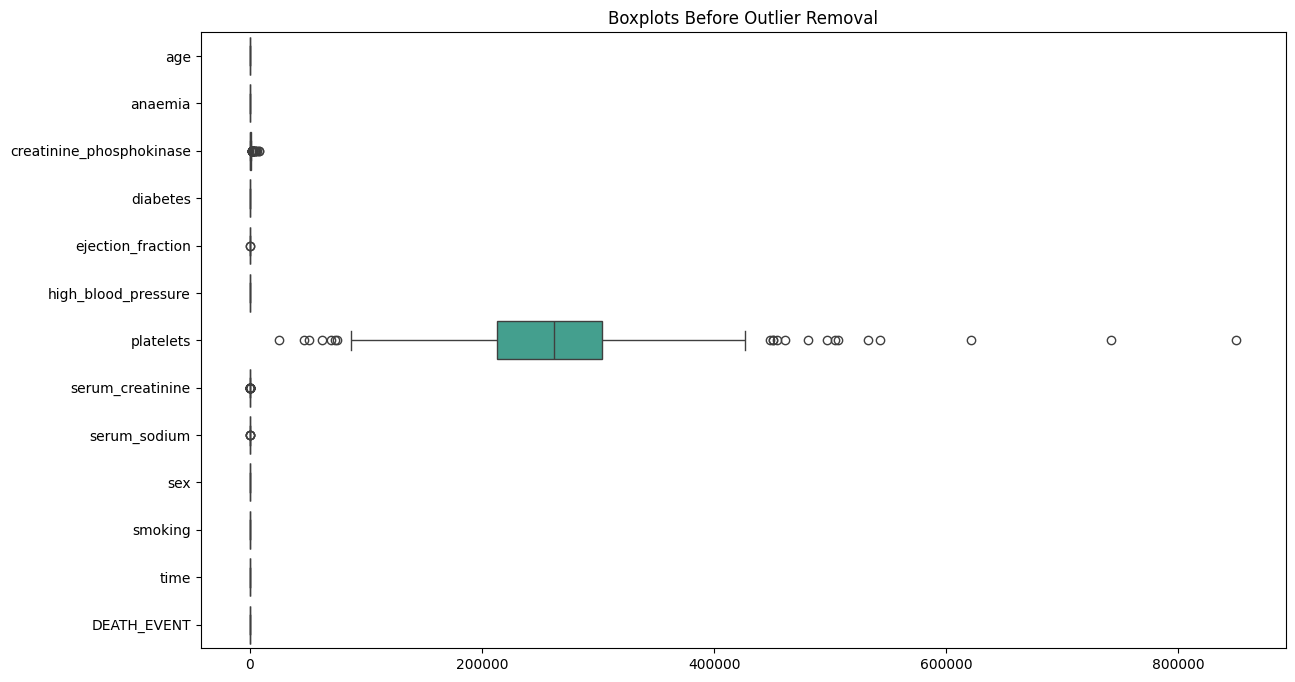

In [12]:
# Boxplots Before Cleaning

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df[numerical_columns],
    orient="h"
)

plt.title("Boxplots Before Outlier Removal")
plt.show()

Numerical Features:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']


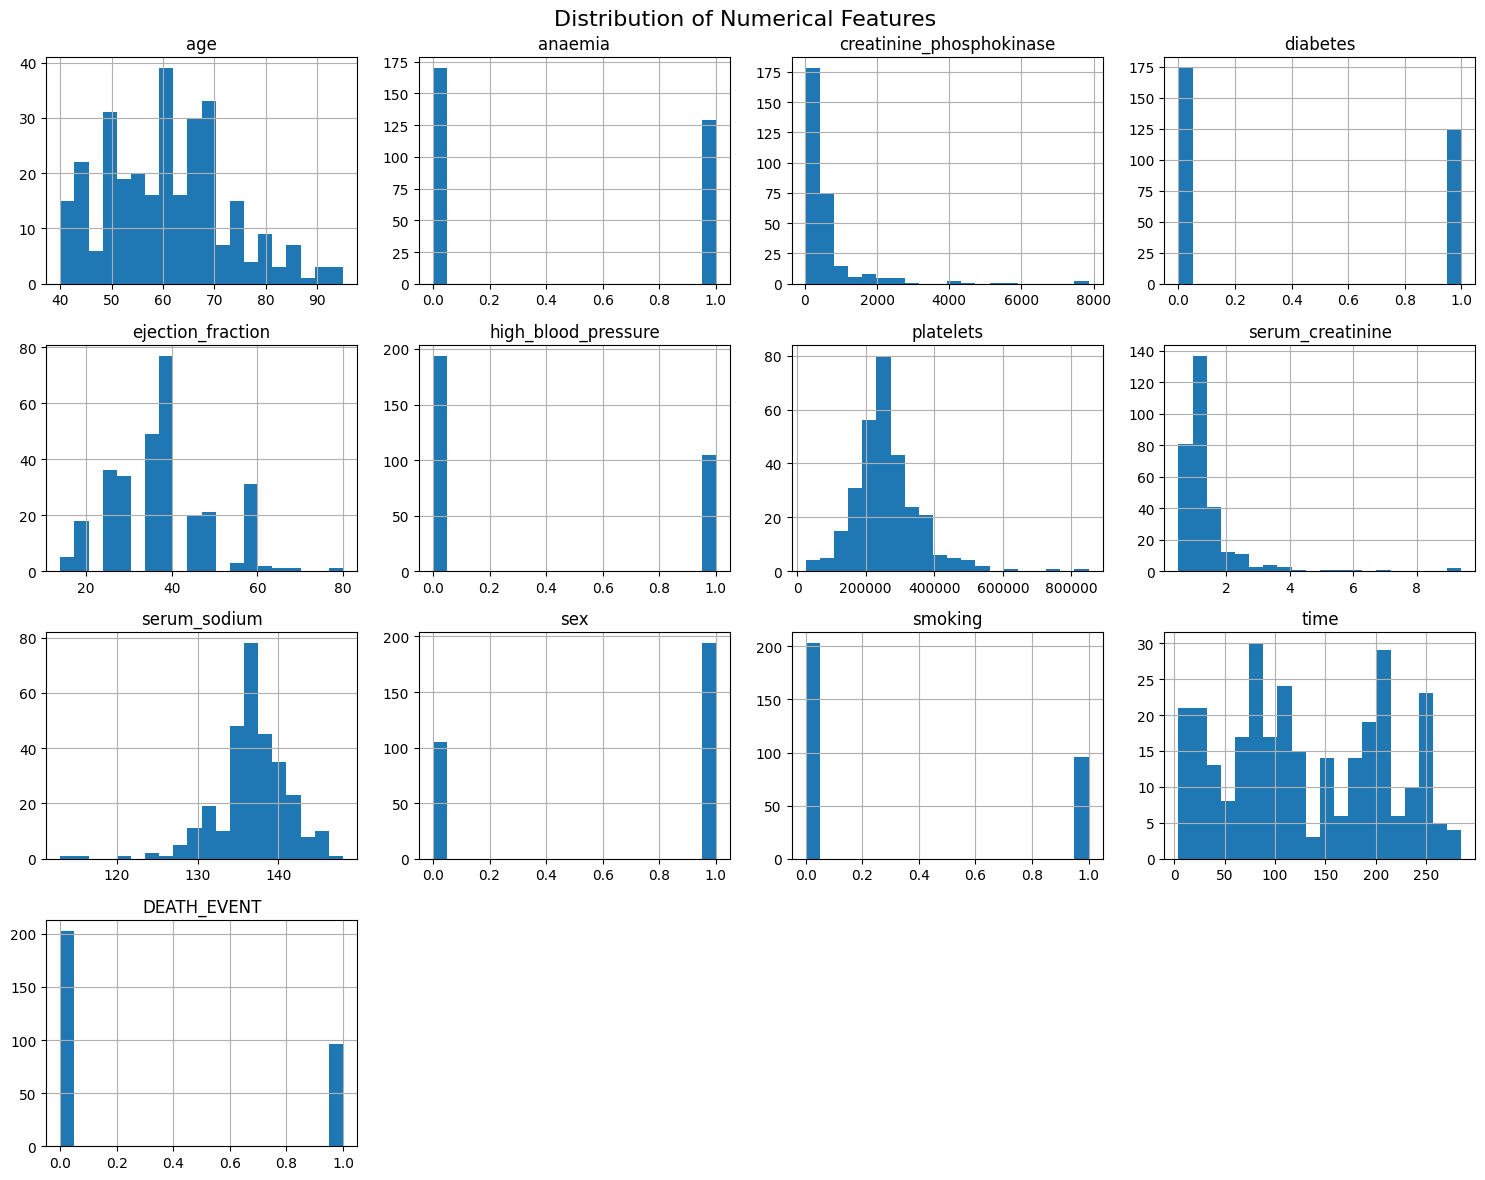

In [13]:
# Task 5: Plot Distributions of Numerical Features

numerical_columns = df.select_dtypes(include='number').columns

print("Numerical Features:")
print(list(numerical_columns))

# Plot histograms
df[numerical_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

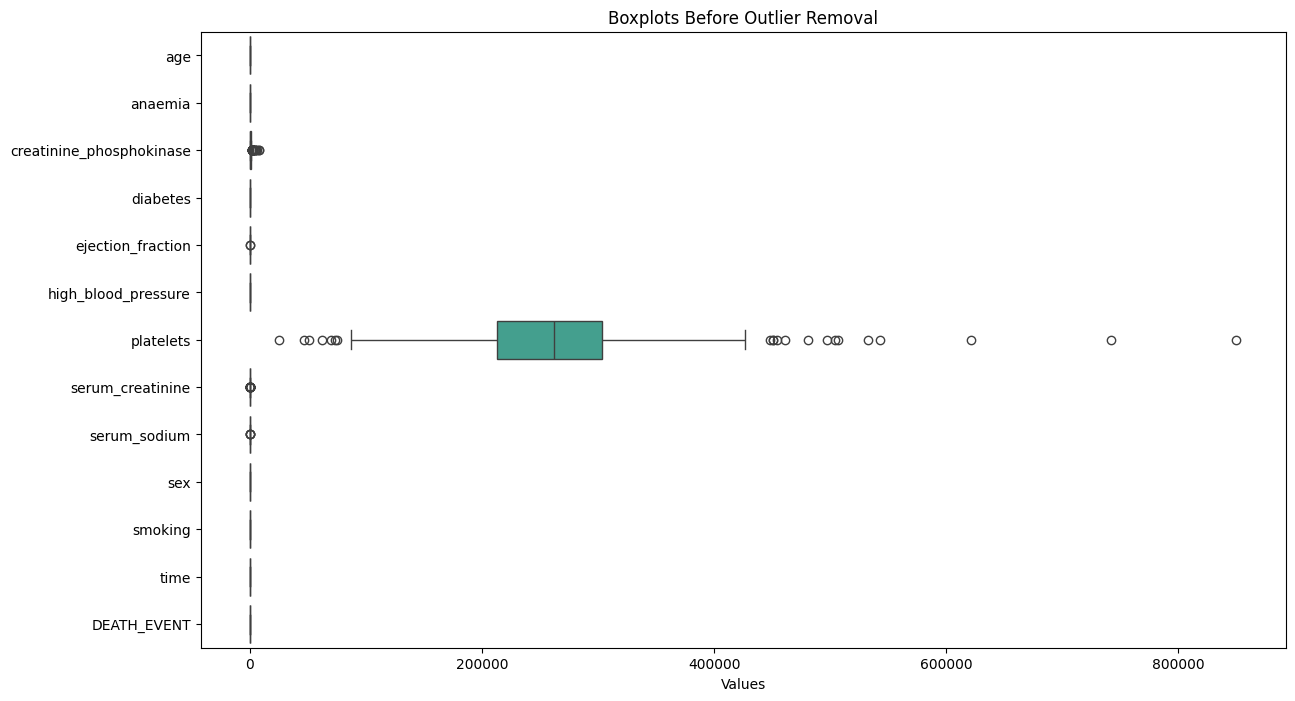

In [14]:
# Boxplots Before Cleaning

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df[numerical_columns],
    orient="h"
)

plt.title("Boxplots Before Outlier Removal")
plt.xlabel("Values")

plt.show()

In [15]:
# Task 6: Impute Missing Values

# Check missing values before imputation
print("Missing values BEFORE imputation:")
print(df.isnull().sum())

# Identify numerical and categorical columns
numerical_columns = df.select_dtypes(include='number').columns
categorical_columns = df.select_dtypes(exclude='number').columns

# Fill numerical missing values with median
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values AFTER imputation:")
print(df.isnull().sum())

Missing values BEFORE imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Missing values AFTER imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [16]:
# Task 7: Remove Outliers using IQR

# Save original number of rows
original_rows = df.shape[0]

# Function to remove outliers
def remove_outliers_iqr(data, columns):
    cleaned_data = data.copy()

    for col in columns:
        Q1 = cleaned_data[col].quantile(0.25)
        Q3 = cleaned_data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        cleaned_data = cleaned_data[
            (cleaned_data[col] >= lower_bound) &
            (cleaned_data[col] <= upper_bound)
        ]

    return cleaned_data

# Remove outliers
df_clean = remove_outliers_iqr(df, numerical_columns)

print("Rows before outlier removal:", original_rows)
print("Rows after outlier removal:", df_clean.shape[0])
print("Rows removed:", original_rows - df_clean.shape[0])

Rows before outlier removal: 299
Rows after outlier removal: 224
Rows removed: 75


In [17]:
# Task 8: Correct Inconsistencies

# Check for negative age values
print("Negative age values:")
print((df_clean['age'] < 0).sum())

# Check minimum and maximum age
print("\nAge range:")
print("Minimum age:", df_clean['age'].min())
print("Maximum age:", df_clean['age'].max())

# Correct negative age values if any exist
if (df_clean['age'] < 0).sum() > 0:
    median_age = df_clean.loc[df_clean['age'] >= 0, 'age'].median()
    df_clean.loc[df_clean['age'] < 0, 'age'] = median_age

# Check other numerical columns for negative values
print("\nNegative values in numerical columns:")

for col in numerical_columns:
    negative_count = (df_clean[col] < 0).sum()
    print(f"{col}: {negative_count}")

Negative age values:
0

Age range:
Minimum age: 40.0
Maximum age: 95.0

Negative values in numerical columns:
age: 0
anaemia: 0
creatinine_phosphokinase: 0
diabetes: 0
ejection_fraction: 0
high_blood_pressure: 0
platelets: 0
serum_creatinine: 0
serum_sodium: 0
sex: 0
smoking: 0
time: 0
DEATH_EVENT: 0


In [18]:
# Verify corrected data

print("Minimum age after correction:", df_clean['age'].min())

print("\nAny negative ages remaining?")
print((df_clean['age'] < 0).sum())

Minimum age after correction: 40.0

Any negative ages remaining?
0


In [19]:
# Task 9: Feature Engineering

# 1. Create age_group
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 40, 60, float('inf')],
    labels=['<40', '40-60', '>60'],
    right=False
)

# Display age groups
print("Age Group Distribution:")
print(df_clean['age_group'].value_counts())

print("\nSample age groups:")
display(df_clean[['age', 'age_group']].head(10))

Age Group Distribution:
age_group
>60      125
40-60     99
<40        0
Name: count, dtype: int64

Sample age groups:


,age,age_group
0,75.0,>60
2,65.0,>60
3,50.0,40-60
5,90.0,>60
6,75.0,>60
8,65.0,>60
11,62.0,>60
12,45.0,40-60
13,50.0,40-60
14,49.0,40-60


In [20]:
# Create risk_score

# Product of ejection_fraction and serum_creatinine
df_clean['risk_score'] = (
    df_clean['ejection_fraction'] *
    df_clean['serum_creatinine']
)

# Normalize risk_score to 0-1
min_value = df_clean['risk_score'].min()
max_value = df_clean['risk_score'].max()

df_clean['risk_score'] = (
    (df_clean['risk_score'] - min_value) /
    (max_value - min_value)
)

print("Risk Score created successfully!")

display(
    df_clean[
        ['ejection_fraction', 'serum_creatinine', 'risk_score']
    ].head(10)
)

Risk Score created successfully!


,ejection_fraction,serum_creatinine,risk_score
0,20,1.9,0.310545
2,20,1.3,0.171495
3,20,1.9,0.310545
5,40,2.1,0.843569
6,15,1.2,0.078795
8,65,1.5,1.000000
11,25,0.9,0.130939
12,30,1.1,0.252607
13,38,1.1,0.354577
14,30,1.0,0.217845


In [21]:
# Verify Task 9

print("Dataset shape:", df_clean.shape)

print("\nNew Features:")
print(df_clean[['age_group', 'risk_score']].head())

print("\nRisk Score range:")
print("Minimum:", df_clean['risk_score'].min())
print("Maximum:", df_clean['risk_score'].max())

Dataset shape: (224, 15)

New Features:
  age_group  risk_score
0       >60    0.310545
2       >60    0.171495
3     40-60    0.310545
5       >60    0.843569
6       >60    0.078795

Risk Score range:
Minimum: 0.0
Maximum: 1.0


In [22]:
# Task 10: Encode Categorical Variables

# Find categorical columns
categorical_columns = df_clean.select_dtypes(
    include=['object', 'category']
).columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['age_group']


In [23]:
# One-hot encode categorical variables

df_encoded = pd.get_dummies(
    df_clean,
    columns=categorical_columns,
    drop_first=True
)

print("Dataset shape before encoding:", df_clean.shape)
print("Dataset shape after encoding:", df_encoded.shape)

display(df_encoded.head())

Dataset shape before encoding: (224, 15)
Dataset shape after encoding: (224, 16)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_40-60,age_group_>60
0,75.0,0,582,0,20,1,265000.0,1.9,130,1,0,4,1,0.310545,False,True
2,65.0,0,146,0,20,0,162000.0,1.3,129,1,1,7,1,0.171495,False,True
3,50.0,1,111,0,20,0,210000.0,1.9,137,1,0,7,1,0.310545,True,False
5,90.0,1,47,0,40,1,204000.0,2.1,132,1,1,8,1,0.843569,False,True
6,75.0,1,246,0,15,0,127000.0,1.2,137,1,0,10,1,0.078795,False,True


In [24]:
# Verify categorical encoding

print("Columns after encoding:")
print(df_encoded.columns.tolist())

print("\nData types:")
print(df_encoded.dtypes)

Columns after encoding:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'risk_score', 'age_group_40-60', 'age_group_>60']

Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
risk_score                  float64
age_group_40-60                bool
age_group_>60                  bool
dtype: object


In [25]:
# Task 11: Normalize Numerical Features

from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns
numerical_columns_final = df_encoded.select_dtypes(
    include='number'
).columns

print("Numerical columns:")
print(list(numerical_columns_final))

# Create MinMaxScaler
scaler = MinMaxScaler()

# Apply normalization
df_encoded[numerical_columns_final] = scaler.fit_transform(
    df_encoded[numerical_columns_final]
)

print("\n✅ Numerical features normalized successfully!")

display(df_encoded.head())

Numerical columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'risk_score']

✅ Numerical features normalized successfully!


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_40-60,age_group_>60
0,0.636364,0.0,0.470990,0.0,0.117647,1.0,0.468852,0.866667,0.217391,1.0,0.0,0.000000,1.0,0.310545,False,True
2,0.454545,0.0,0.098976,0.0,0.117647,0.0,0.131148,0.466667,0.173913,1.0,1.0,0.010676,1.0,0.171495,False,True
3,0.181818,1.0,0.069113,0.0,0.117647,0.0,0.288525,0.866667,0.521739,1.0,0.0,0.010676,1.0,0.310545,True,False
5,0.909091,1.0,0.014505,0.0,0.509804,1.0,0.268852,1.000000,0.304348,1.0,1.0,0.014235,1.0,0.843569,False,True
6,0.636364,1.0,0.184300,0.0,0.019608,0.0,0.016393,0.400000,0.521739,1.0,0.0,0.021352,1.0,0.078795,False,True


In [26]:
# Verify normalization

print("Minimum values:")
print(df_encoded[numerical_columns_final].min())

print("\nMaximum values:")
print(df_encoded[numerical_columns_final].max())

Minimum values:
age                         0.0
anaemia                     0.0
creatinine_phosphokinase    0.0
diabetes                    0.0
ejection_fraction           0.0
high_blood_pressure         0.0
platelets                   0.0
serum_creatinine            0.0
serum_sodium                0.0
sex                         0.0
smoking                     0.0
time                        0.0
DEATH_EVENT                 0.0
risk_score                  0.0
dtype: float64

Maximum values:
age                         1.0
anaemia                     1.0
creatinine_phosphokinase    1.0
diabetes                    1.0
ejection_fraction           1.0
high_blood_pressure         1.0
platelets                   1.0
serum_creatinine            1.0
serum_sodium                1.0
sex                         1.0
smoking                     1.0
time                        1.0
DEATH_EVENT                 1.0
risk_score                  1.0
dtype: float64


In [27]:
print("Minimum value in dataset:",
      df_encoded[numerical_columns_final].min().min())

print("Maximum value in dataset:",
      df_encoded[numerical_columns_final].max().max())

Minimum value in dataset: 0.0
Maximum value in dataset: 1.0


In [28]:
# Task 12: Summary Statistics BEFORE Cleaning

before_stats = df.describe().T

before_stats = before_stats[
    ['mean', '50%', 'std']
]

before_stats.rename(
    columns={'50%': 'median'},
    inplace=True
)

print("Summary Statistics BEFORE Cleaning:")
display(before_stats)

Summary Statistics BEFORE Cleaning:


,mean,median,std
age,60.833893,60.0,11.894809
anaemia,0.431438,0.0,0.496107
creatinine_phosphokinase,581.839465,250.0,970.287881
diabetes,0.418060,0.0,0.494067
ejection_fraction,38.083612,38.0,11.834841
high_blood_pressure,0.351171,0.0,0.478136
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510
serum_sodium,136.625418,137.0,4.412477
sex,0.648829,1.0,0.478136


In [29]:
# Summary Statistics AFTER Cleaning

after_stats = df_encoded.describe().T

after_stats = after_stats[
    ['mean', '50%', 'std']
]

after_stats.rename(
    columns={'50%': 'median'},
    inplace=True
)

print("Summary Statistics AFTER Cleaning:")
display(after_stats)

Summary Statistics AFTER Cleaning:


,mean,median,std
age,0.378355,0.363636,0.217202
anaemia,0.468750,0.000000,0.500140
creatinine_phosphokinase,0.261896,0.155290,0.238499
diabetes,0.419643,0.000000,0.494606
ejection_fraction,0.474090,0.470588,0.229624
high_blood_pressure,0.379464,0.000000,0.486340
platelets,0.438902,0.460656,0.220176
serum_creatinine,0.352381,0.333333,0.218530
serum_sodium,0.523680,0.521739,0.165510
sex,0.642857,1.000000,0.480231


In [30]:
# Comparison of Mean, Median and Standard Deviation

print("BEFORE CLEANING")
display(before_stats)

print("\nAFTER CLEANING")
display(after_stats)

BEFORE CLEANING


,mean,median,std
age,60.833893,60.0,11.894809
anaemia,0.431438,0.0,0.496107
creatinine_phosphokinase,581.839465,250.0,970.287881
diabetes,0.418060,0.0,0.494067
ejection_fraction,38.083612,38.0,11.834841
high_blood_pressure,0.351171,0.0,0.478136
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510
serum_sodium,136.625418,137.0,4.412477
sex,0.648829,1.0,0.478136



AFTER CLEANING


,mean,median,std
age,0.378355,0.363636,0.217202
anaemia,0.468750,0.000000,0.500140
creatinine_phosphokinase,0.261896,0.155290,0.238499
diabetes,0.419643,0.000000,0.494606
ejection_fraction,0.474090,0.470588,0.229624
high_blood_pressure,0.379464,0.000000,0.486340
platelets,0.438902,0.460656,0.220176
serum_creatinine,0.352381,0.333333,0.218530
serum_sodium,0.523680,0.521739,0.165510
sex,0.642857,1.000000,0.480231


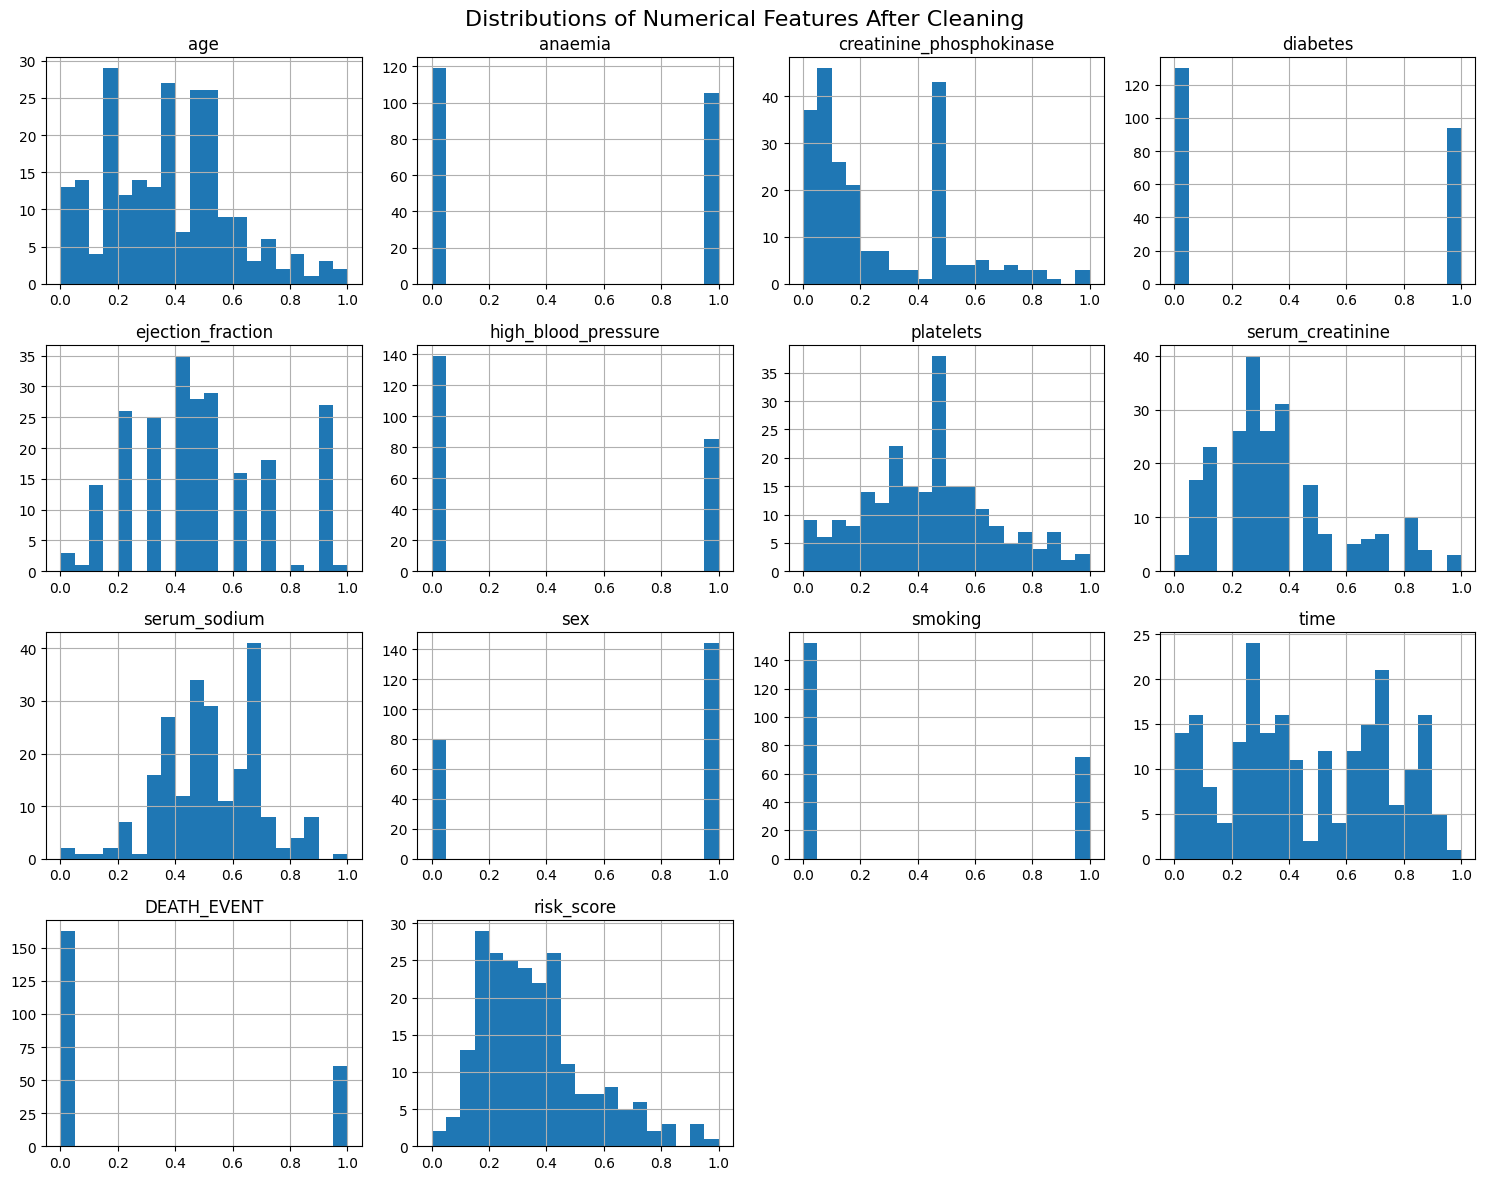

In [31]:
# Task 13: Validate Cleaning
# Histograms of cleaned numerical features

df_encoded[numerical_columns_final].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distributions of Numerical Features After Cleaning",
    fontsize=16
)

plt.tight_layout()
plt.show()

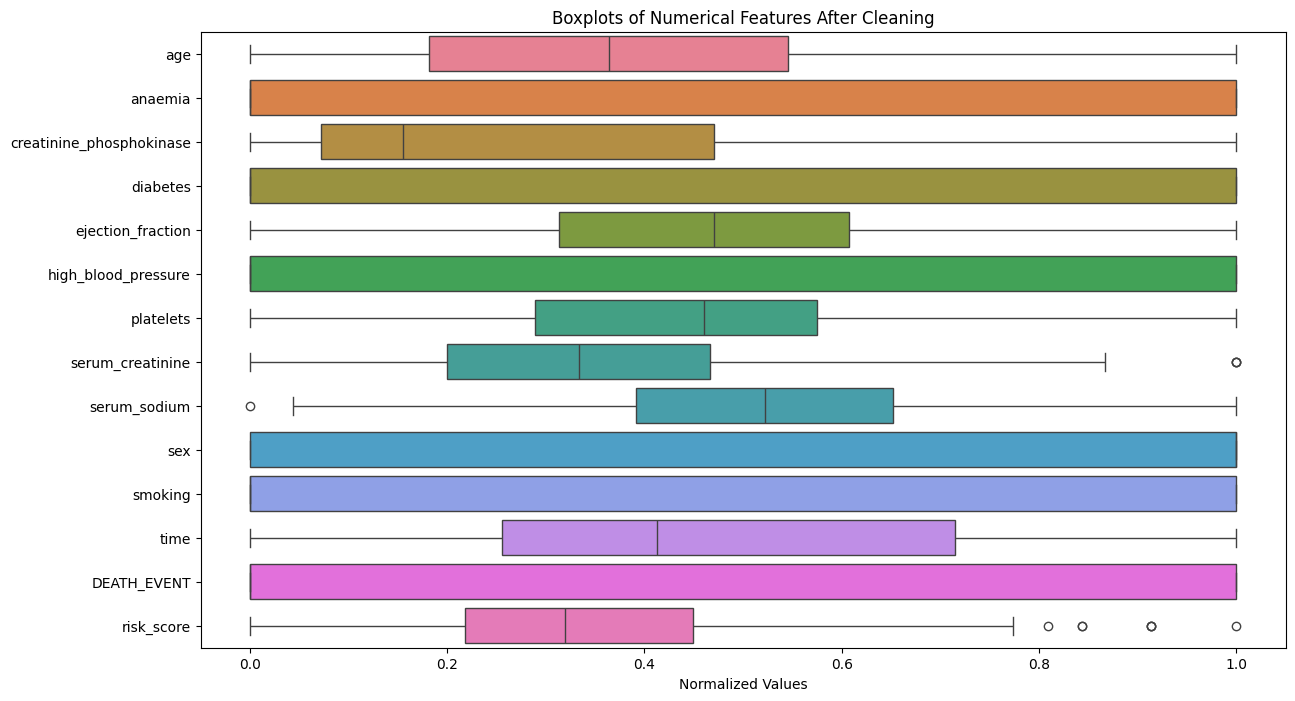

In [32]:
# Boxplots of cleaned numerical features

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df_encoded[numerical_columns_final],
    orient="h"
)

plt.title("Boxplots of Numerical Features After Cleaning")
plt.xlabel("Normalized Values")

plt.show()

In [33]:
# Final dataset validation

print("Final dataset shape:", df_encoded.shape)

print("\nFirst 5 rows of cleaned dataset:")
display(df_encoded.head())

Final dataset shape: (224, 16)

First 5 rows of cleaned dataset:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_40-60,age_group_>60
0,0.636364,0.0,0.470990,0.0,0.117647,1.0,0.468852,0.866667,0.217391,1.0,0.0,0.000000,1.0,0.310545,False,True
2,0.454545,0.0,0.098976,0.0,0.117647,0.0,0.131148,0.466667,0.173913,1.0,1.0,0.010676,1.0,0.171495,False,True
3,0.181818,1.0,0.069113,0.0,0.117647,0.0,0.288525,0.866667,0.521739,1.0,0.0,0.010676,1.0,0.310545,True,False
5,0.909091,1.0,0.014505,0.0,0.509804,1.0,0.268852,1.000000,0.304348,1.0,1.0,0.014235,1.0,0.843569,False,True
6,0.636364,1.0,0.184300,0.0,0.019608,0.0,0.016393,0.400000,0.521739,1.0,0.0,0.021352,1.0,0.078795,False,True


In [34]:
# Task 14: Final Missing Values Check

print("Missing Values in Final Dataset:")
print(df_encoded.isnull().sum())

# Calculate total missing values
total_missing = df_encoded.isnull().sum().sum()

print("\nTotal Missing Values:", total_missing)

if total_missing == 0:
    print("\n✅ VALIDATION SUCCESSFUL")
    print("No missing values remain in the cleaned dataset.")
else:
    print("\n⚠️ Missing values still remain.")

Missing Values in Final Dataset:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_40-60             0
age_group_>60               0
dtype: int64

Total Missing Values: 0

✅ VALIDATION SUCCESSFUL
No missing values remain in the cleaned dataset.


In [35]:
# Final Dataset Summary

print("========== FINAL DATASET SUMMARY ==========")

print("Rows:", df_encoded.shape[0])
print("Columns:", df_encoded.shape[1])

print("\nMissing Values:", df_encoded.isnull().sum().sum())

print("\nMinimum value:", df_encoded.min(numeric_only=True).min())
print("Maximum value:", df_encoded.max(numeric_only=True).max())

print("\nFinal Columns:")
print(df_encoded.columns.tolist())

print("\nFirst 5 rows:")
display(df_encoded.head())

========== FINAL DATASET SUMMARY ==========
Rows: 224
Columns: 16

Missing Values: 0

Minimum value: 0.0
Maximum value: 1.0

Final Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'risk_score', 'age_group_40-60', 'age_group_>60']

First 5 rows:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_40-60,age_group_>60
0,0.636364,0.0,0.470990,0.0,0.117647,1.0,0.468852,0.866667,0.217391,1.0,0.0,0.000000,1.0,0.310545,False,True
2,0.454545,0.0,0.098976,0.0,0.117647,0.0,0.131148,0.466667,0.173913,1.0,1.0,0.010676,1.0,0.171495,False,True
3,0.181818,1.0,0.069113,0.0,0.117647,0.0,0.288525,0.866667,0.521739,1.0,0.0,0.010676,1.0,0.310545,True,False
5,0.909091,1.0,0.014505,0.0,0.509804,1.0,0.268852,1.000000,0.304348,1.0,1.0,0.014235,1.0,0.843569,False,True
6,0.636364,1.0,0.184300,0.0,0.019608,0.0,0.016393,0.400000,0.521739,1.0,0.0,0.021352,1.0,0.078795,False,True


In [36]:
# Save the final cleaned dataset

output_file = "/content/final_cleaned_heart_failure_dataset.csv"

df_encoded.to_csv(output_file, index=False)

print("✅ Final cleaned dataset saved as:")
print(output_file)

✅ Final cleaned dataset saved as:
/content/final_cleaned_heart_failure_dataset.csv
